In [111]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Kupina MovieLens Analysis")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Spark application:", spark.sparkContext.appName)

ConnectionRefusedError: [WinError 10061] No connection could be made because the target machine actively refused it

In [ ]:
import sys

print(sys.executable)
print(sys.version)

# Sistem za preporuku filmova korišćenjem Apache Spark-a

## Uvod

U ovom notebook-u prikazan je kompletan proces analize MovieLens skupa podataka korišćenjem Apache Spark-a.

Cilj analize je razvoj sistema za preporuku filmova primenom **ALS (Alternating Least Squares)** algoritma, koji predstavlja jedan od najpoznatijih algoritama za kolaborativno filtriranje.

MovieLens skup podataka prethodno je importovan u MongoDB bazu podataka, odakle će biti učitan u Apache Spark radi dalje obrade i analize.

Notebook obuhvata sledeće korake:

- pokretanje Apache Spark okruženja,
- učitavanje podataka iz MongoDB baze,
- analizu skupa podataka,
- pripremu podataka za treniranje modela,
- treniranje ALS modela,
- evaluaciju uspešnosti modela,
- generisanje personalizovanih preporuka za korisnike.

# 1. Pokretanje Spark sesije

Apache Spark predstavlja distribuirani sistem za obradu velikih količina podataka.

Za rad sa Spark-om neophodno je kreirati Spark sesiju (*SparkSession*), koja predstavlja ulaznu tačku za izvršavanje svih Spark operacija.

U nastavku se učitavaju potrebne biblioteke i pokreće Spark sesija koja će biti korišćena tokom kompletne analize.

In [1]:
import os

os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["hadoop.home.dir"] = r"C:\hadoop"
os.environ["PATH"] = r"C:\hadoop\bin" + os.pathsep + os.environ["PATH"]

In [2]:
import os

print("HADOOP_HOME:", os.environ.get("HADOOP_HOME"))
print(
    "winutils postoji:",
    os.path.isfile(r"C:\hadoop\bin\winutils.exe")
)

HADOOP_HOME: C:\hadoop
winutils postoji: True


In [3]:
# Uvoz potrebnih biblioteka

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    when,
    sum,
    count,
    avg,
    desc,
    regexp_extract,
    split,
    explode,
    year
)
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Kreiranje Spark sesije

spark = (
    SparkSession.builder
    .appName("Kupina Movie Recommendation System")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

In [ ]:
# Prikaz osnovnih informacija o Spark sesiji

print("Spark version:", spark.version)
print("Application name:", spark.sparkContext.appName)

### Zaključak

Spark sesija je uspešno pokrenuta i spremna za rad.

U narednom koraku podaci će biti učitani direktno iz MongoDB baze i konvertovani u Spark DataFrame-ove, koji predstavljaju osnovnu strukturu podataka za dalju obradu u Apache Spark okruženju.

In [ ]:
# Zaustavljanje postojeće Spark sesije pre dodavanja MongoDB konektora

try:
    spark.stop()
except NameError:
    pass

In [ ]:
import pyspark
print(pyspark.__version__)
print(pyspark.__file__)

In [4]:
import os
print(os.environ.get("SPARK_HOME"))

None


In [5]:
import os
print(os.environ.get("HADOOP_HOME"))

C:\hadoop


In [6]:
# Kreiranje Spark sesije sa MongoDB Spark Connector paketom

import os

os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["hadoop.home.dir"] = r"C:\hadoop"
os.environ["PATH"] = r"C:\hadoop\bin" + os.pathsep + os.environ["PATH"]

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Kupina Movie Recommendation System")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config(
        "spark.jars.packages",
        "org.mongodb.spark:mongo-spark-connector_2.13:11.1.0"
    )
    .config(
        "spark.mongodb.read.connection.uri",
        "mongodb://127.0.0.1:27017/kupina"
    )
    .config(
        "spark.mongodb.write.connection.uri",
        "mongodb://127.0.0.1:27017/kupina"
    )
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Application name:", spark.sparkContext.appName)

Spark version: 4.2.0
Application name: Kupina Movie Recommendation System


# 2. Učitavanje podataka iz MongoDB baze

MovieLens podaci prethodno su importovani u MongoDB bazu `kupina`.

U ovom koraku kolekcije `movies`, `ratings` i `users` učitavaju se direktno iz MongoDB baze i pretvaraju u Spark DataFrame-ove.

Na ovaj način ostvaruje se direktna veza između dela aplikacije koji koristi MongoDB i dela projekta namenjenog distribuiranoj obradi podataka i mašinskom učenju.

In [7]:
# Učitavanje kolekcije sa filmovima

movies_df = (
    spark.read
    .format("mongodb")
    .option("database", "kupina")
    .option("collection", "movies")
    .load()
)

In [8]:
# Učitavanje kolekcije sa ocenama

ratings_df = (
    spark.read
    .format("mongodb")
    .option("database", "kupina")
    .option("collection", "ratings")
    .load()
)

In [9]:
# Učitavanje kolekcije sa MovieLens korisnicima

users_df = (
    spark.read
    .format("mongodb")
    .option("database", "kupina")
    .option("collection", "users")
    .load()
)

In [10]:
# Prikaz broja zapisa u učitanim kolekcijama

print("Number of movies:", movies_df.count())
print("Number of ratings:", ratings_df.count())
print("Number of users:", users_df.count())

Number of movies: 3883
Number of ratings: 1000211
Number of users: 6040


In [11]:
# Prikaz prvih zapisa iz kolekcije movies

# movies_df.show(5, truncate=False)
movies_df.show(5)

+--------------------+--------------------+--------------------+-------+--------------------+--------------------+--------------------+
|                 _id|            backdrop|              genres|movieId|            overview|              poster|               title|
+--------------------+--------------------+--------------------+-------+--------------------+--------------------+--------------------+
|6a50f32270e9367e4...|https://image.tmd...|Animation|Childre...|      1|Led by Woody, And...|https://image.tmd...|    Toy Story (1995)|
|6a50f32270e9367e4...|https://image.tmd...|Adventure|Childre...|      2|When siblings Jud...|https://image.tmd...|      Jumanji (1995)|
|6a50f32270e9367e4...|https://image.tmd...|      Comedy|Romance|      3|A family wedding ...|https://image.tmd...|Grumpier Old Men ...|
|6a50f32270e9367e4...|https://image.tmd...|        Comedy|Drama|      4|Cheated on, mistr...|https://image.tmd...|Waiting to Exhale...|
|6a50f32270e9367e4...|https://image.tmd...|     

In [12]:
# Prikaz prvih zapisa iz kolekcije ratings

ratings_df.show(5, truncate=False)

+------------------------+-------+------+---------+------+
|_id                     |movieId|rating|timestamp|userId|
+------------------------+-------+------+---------+------+
|6a50f32b6acf486a47ea84e2|1193   |5     |978300760|1     |
|6a50f32b6acf486a47ea84e3|661    |3     |978302109|1     |
|6a50f32b6acf486a47ea84e4|914    |3     |978301968|1     |
|6a50f32b6acf486a47ea84e5|3408   |4     |978300275|1     |
|6a50f32b6acf486a47ea84e6|2355   |5     |978824291|1     |
+------------------------+-------+------+---------+------+
only showing top 5 rows


In [13]:
# Prikaz prvih zapisa iz kolekcije users

users_df.show(5, truncate=False)

+------------------------+---+------+----------+------+-------+
|_id                     |age|gender|occupation|userId|zipCode|
+------------------------+---+------+----------+------+-------+
|6a50f318a4e716eb8ec3db1c|56 |M     |16        |2     |70072  |
|6a50f318a4e716eb8ec3db1d|25 |M     |15        |3     |55117  |
|6a50f318a4e716eb8ec3db1e|45 |M     |7         |4     |2460   |
|6a50f318a4e716eb8ec3db1f|1  |F     |10        |1     |48067  |
|6a50f318a4e716eb8ec3db20|50 |F     |9         |6     |55117  |
+------------------------+---+------+----------+------+-------+
only showing top 5 rows


### Zaključak

Podaci iz MongoDB baze uspešno su učitani u Spark DataFrame-ove.

Dobijeni DataFrame-ovi sadrže podatke o filmovima, korisnicima i ocenama i predstavljaće osnovu za dalju analizu i treniranje ALS modela.

# 3. Pregled i provera kvaliteta podataka

Pre treniranja modela potrebno je proveriti strukturu učitanih DataFrame-ova, tipove atributa, broj nedostajućih vrednosti i eventualne duplikate.

Ovaj korak je važan jer ALS model zahteva ispravna numerička polja `userId`, `movieId` i `rating`.

In [14]:
# Prikaz strukture učitanih DataFrame-ova

print("Movies schema:")
movies_df.printSchema()

print("Ratings schema:")
ratings_df.printSchema()

print("Users schema:")
users_df.printSchema()

Movies schema:
root
 |-- _id: string (nullable = true)
 |-- backdrop: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- overview: string (nullable = true)
 |-- poster: string (nullable = true)
 |-- title: string (nullable = true)

Ratings schema:
root
 |-- _id: string (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: integer (nullable = true)
 |-- timestamp: integer (nullable = true)
 |-- userId: integer (nullable = true)

Users schema:
root
 |-- _id: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- occupation: integer (nullable = true)
 |-- userId: integer (nullable = true)
 |-- zipCode: string (nullable = true)



In [15]:
# Prikaz naziva kolona

print("Movies columns:", movies_df.columns)
print("Ratings columns:", ratings_df.columns)
print("Users columns:", users_df.columns)

Movies columns: ['_id', 'backdrop', 'genres', 'movieId', 'overview', 'poster', 'title']
Ratings columns: ['_id', 'movieId', 'rating', 'timestamp', 'userId']
Users columns: ['_id', 'age', 'gender', 'occupation', 'userId', 'zipCode']


In [16]:
# Brojanje nedostajućih vrednosti po kolonama

def show_missing_values(dataframe, dataframe_name):
    missing_values = dataframe.select([
        sum(
            when(col(column).isNull(), 1).otherwise(0)
        ).alias(column)
        for column in dataframe.columns
    ])

    print(f"Missing values in {dataframe_name}:")
    missing_values.show(truncate=False)


show_missing_values(movies_df, "movies")
show_missing_values(ratings_df, "ratings")
show_missing_values(users_df, "users")

Missing values in movies:
+---+--------+------+-------+--------+------+-----+
|_id|backdrop|genres|movieId|overview|poster|title|
+---+--------+------+-------+--------+------+-----+
|0  |345     |0     |0      |234     |235   |0    |
+---+--------+------+-------+--------+------+-----+

Missing values in ratings:
+---+-------+------+---------+------+
|_id|movieId|rating|timestamp|userId|
+---+-------+------+---------+------+
|0  |0      |0     |0        |0     |
+---+-------+------+---------+------+

Missing values in users:
+---+---+------+----------+------+-------+
|_id|age|gender|occupation|userId|zipCode|
+---+---+------+----------+------+-------+
|0  |0  |0     |0         |0     |0      |
+---+---+------+----------+------+-------+



In [17]:
# Provera duplikata u ključnim kolonama

duplicate_movies = (
    movies_df
    .groupBy("movieId")
    .count()
    .filter(col("count") > 1)
    .count()
)

duplicate_ratings = (
    ratings_df
    .groupBy("userId", "movieId")
    .count()
    .filter(col("count") > 1)
    .count()
)

duplicate_users = (
    users_df
    .groupBy("userId")
    .count()
    .filter(col("count") > 1)
    .count()
)

print("Duplicate movie IDs:", duplicate_movies)
print("Duplicate user-movie ratings:", duplicate_ratings)
print("Duplicate user IDs:", duplicate_users)

Duplicate movie IDs: 0
Duplicate user-movie ratings: 0
Duplicate user IDs: 0


In [18]:
# Osnovni statistički pregled ocena i identifikatora

ratings_df.select(
    "userId",
    "movieId",
    "rating"
).describe().show()

+-------+------------------+------------------+------------------+
|summary|            userId|           movieId|            rating|
+-------+------------------+------------------+------------------+
|  count|           1000211|           1000211|           1000211|
|   mean| 3024.518381621478| 1865.536175866892|3.5815632901457795|
| stddev|1728.4162337031019|1096.0427546563014|1.1171019261904678|
|    min|                 1|                 1|                 1|
|    max|              6042|              3952|                 5|
+-------+------------------+------------------+------------------+



### Zaključak

Izvršena je provera strukture, nedostajućih vrednosti i duplikata u učitanim podacima.

Na osnovu dobijenih rezultata biće izvršeno potrebno čišćenje podataka pre daljih analiza i treniranja ALS modela.

# 4. Eksplorativna analiza podataka

Nakon učitavanja i provere kvaliteta podataka, sledi analiza osnovnih karakteristika MovieLens skupa podataka.

Cilj ovog dela je sticanje uvida u strukturu podataka i raspodelu ocena, korisnika i filmova, što predstavlja važan korak pre treniranja sistema za preporuku.

## 4.1 Osnovne informacije o skupu podataka

Najpre će biti prikazan ukupan broj filmova, korisnika i ocena koji se nalaze u bazi podataka.

In [19]:
# Broj filmova, korisnika i ocena

number_of_movies = movies_df.count()
number_of_users = users_df.count()
number_of_ratings = ratings_df.count()

print(f"Broj filmova: {number_of_movies}")
print(f"Broj korisnika: {number_of_users}")
print(f"Broj ocena: {number_of_ratings}")

Broj filmova: 3883
Broj korisnika: 6040
Broj ocena: 1000211


## 4.2 Osnovna statistika ocena

U ovom koraku analiziraju se osnovne statističke karakteristike ocena koje su korisnici dodelili filmovima.

In [20]:
# Prikaz osnovnih statističkih podataka za ocene

ratings_df.select("rating").describe().show()

+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|           1000211|
|   mean|3.5815632901457795|
| stddev|1.1171019261904513|
|    min|                 1|
|    max|                 5|
+-------+------------------+



### Zaključak

Na osnovu prikazane statistike mogu se uočiti minimalna i maksimalna vrednost ocena, kao i prosečna ocena svih filmova u skupu podataka.

## 4.3 Raspodela ocena

Raspodela ocena omogućava uvid u to koje ocene korisnici najčešće dodeljuju filmovima.

In [21]:
# Broj pojavljivanja svake ocene

rating_distribution = (
    ratings_df
    .groupBy("rating")
    .count()
    .orderBy("rating")
)

rating_distribution.show()

+------+------+
|rating| count|
+------+------+
|     1| 56174|
|     2|107558|
|     3|261197|
|     4|348972|
|     5|226310|
+------+------+



In [ ]:
# %pip uninstall pandas -y
# %pip install "pandas<3"

In [22]:
# Konverzija u Pandas DataFrame radi crtanja grafikona

rating_distribution_pd = rating_distribution.toPandas()

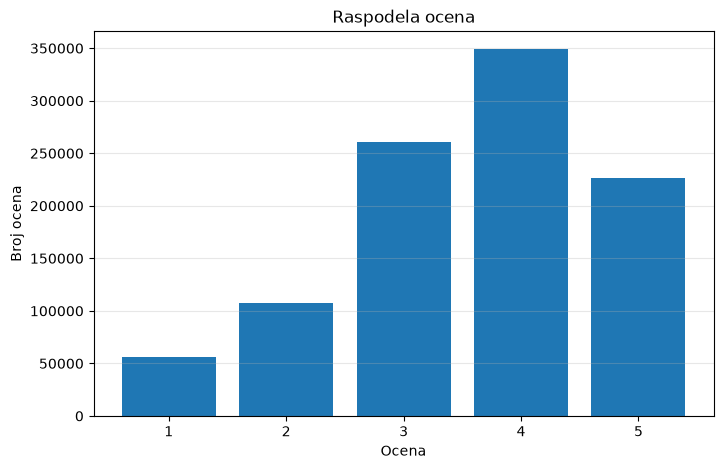

In [23]:
# Prikaz raspodele ocena

plt.figure(figsize=(8,5))

plt.bar(
    rating_distribution_pd["rating"],
    rating_distribution_pd["count"]
)

plt.title("Raspodela ocena")

plt.xlabel("Ocena")

plt.ylabel("Broj ocena")

plt.grid(axis="y", alpha=0.3)

plt.show()

💡 Zanimljivost

Najveći broj korisnika daje ocene između 3 i 5, što ukazuje da MovieLens nije uravnotežen skup podataka i da korisnici češće ocenjuju filmove koje su voleli.

💡 Zanimljivost

Film sa najvećim brojem ocena nije nužno i film sa najvećom prosečnom ocenom.

### Zaključak

Grafikon prikazuje raspodelu ocena koje su korisnici dodelili filmovima.

Na osnovu rezultata može se uočiti da korisnici najčešće dodeljuju više ocene, dok su veoma niske ocene znatno ređe. Ovakva raspodela karakteristična je za MovieLens skup podataka.

## 4.4 Najaktivniji korisnici

U ovom delu analizira se broj ocena koje je dao svaki korisnik.

Na osnovu rezultata moguće je identifikovati korisnike koji su najaktivniji u sistemu i koji imaju najveći uticaj na proces treniranja sistema za preporuku.

In [24]:
# Broj ocena koje je dao svaki korisnik

most_active_users = (
    ratings_df
    .groupBy("userId")
    .count()
    .orderBy(desc("count"))
)

most_active_users.show(10)

+------+-----+
|userId|count|
+------+-----+
|  4169| 2314|
|  1680| 1850|
|  4277| 1743|
|  1941| 1595|
|  1181| 1521|
|   889| 1518|
|  3618| 1344|
|  2063| 1323|
|  1150| 1302|
|  1015| 1286|
+------+-----+
only showing top 10 rows


In [25]:
# Konverzija u Pandas DataFrame

most_active_users_pd = (
    most_active_users
    .limit(10)
    .toPandas()
)

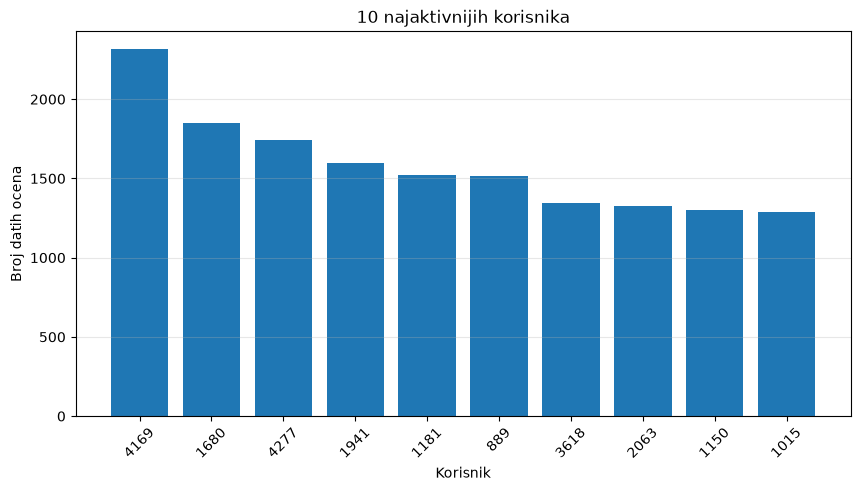

In [26]:
# Prikaz najaktivnijih korisnika

plt.figure(figsize=(10,5))

plt.bar(
    most_active_users_pd["userId"].astype(str),
    most_active_users_pd["count"]
)

plt.title("10 najaktivnijih korisnika")

plt.xlabel("Korisnik")

plt.ylabel("Broj datih ocena")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

### Zaključak

Može se uočiti da pojedini korisnici imaju znatno veći broj ocena u odnosu na ostale.

Ovakvi korisnici predstavljaju značajan izvor informacija za algoritme kolaborativnog filtriranja, jer svojim ocenama povezuju veliki broj filmova.

>💡 Zanimljivost

> U sistemima preporuke korisnici koji ocenjuju veliki broj proizvoda ili filmova često imaju značajan uticaj na kvalitet preporuka, jer algoritam raspolaže većom količinom informacija o njihovim preferencijama.

## 4.5 Filmovi sa najvećim brojem ocena

Popularnost filma može se proceniti na osnovu broja korisnika koji su ga ocenili.

U ovom koraku određuju se filmovi sa najvećim brojem ocena korišćenjem Spark grupisanja i spajanja podataka iz kolekcija **ratings** i **movies**.

In [27]:
# Broj ocena po filmu

movie_rating_counts = (
    ratings_df
    .groupBy("movieId")
    .count()
)

In [28]:
# Spajanje sa kolekcijom filmova radi dobijanja naziva filma

most_rated_movies = (
    movie_rating_counts
    .join(
        movies_df,
        on="movieId",
        how="inner"
    )
    .select(
        "title",
        "genres",
        "count"
    )
    .orderBy(desc("count"))
)

### Objašnjenje

Kolekcija **ratings** sadrži identifikatore filmova (`movieId`), dok se naziv filma nalazi u kolekciji **movies**.

Zbog toga je bilo neophodno izvršiti operaciju spajanja (*join*) kako bi se broj ocena povezao sa odgovarajućim nazivom filma.

In [29]:
# Prikaz 10 filmova sa najvećim brojem ocena

most_rated_movies.show(10, truncate=False)

+-----------------------------------------------------+-----------------------------------+-----+
|title                                                |genres                             |count|
+-----------------------------------------------------+-----------------------------------+-----+
|American Beauty (1999)                               |Comedy|Drama                       |3428 |
|Star Wars: Episode IV - A New Hope (1977)            |Action|Adventure|Fantasy|Sci-Fi    |2991 |
|Star Wars: Episode V - The Empire Strikes Back (1980)|Action|Adventure|Drama|Sci-Fi|War  |2990 |
|Star Wars: Episode VI - Return of the Jedi (1983)    |Action|Adventure|Romance|Sci-Fi|War|2883 |
|Jurassic Park (1993)                                 |Action|Adventure|Sci-Fi            |2672 |
|Saving Private Ryan (1998)                           |Action|Drama|War                   |2653 |
|Terminator 2: Judgment Day (1991)                    |Action|Sci-Fi|Thriller             |2649 |
|Matrix, The (1999) 

In [30]:
# Konverzija u Pandas DataFrame radi vizuelizacije

most_rated_movies_pd = (
    most_rated_movies
    .limit(10)
    .toPandas()
)

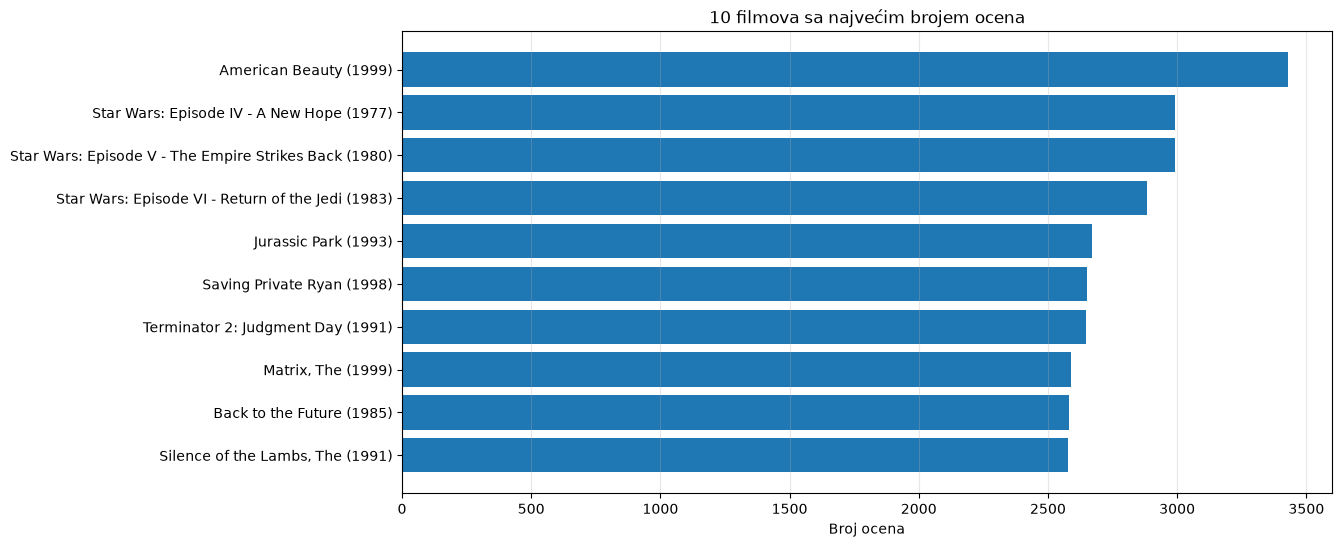

In [31]:
# Vizuelni prikaz najpopularnijih filmova

plt.figure(figsize=(12,6))

plt.barh(
    most_rated_movies_pd["title"],
    most_rated_movies_pd["count"]
)

plt.title("10 filmova sa najvećim brojem ocena")

plt.xlabel("Broj ocena")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.show()

### Zaključak

Rezultati pokazuju da pojedini filmovi imaju značajno veći broj ocena od ostalih.

Veliki broj ocena ukazuje na popularnost filma među korisnicima, ali ne znači nužno da je film i najbolje ocenjen.

> 💡 **Zanimljivost**

> Film sa najvećim brojem ocena nije obavezno i film sa najvećom prosečnom ocenom. Popularnost i kvalitet nisu uvek direktno povezani, zbog čega sistemi preporuke ne mogu da se zasnivaju isključivo na broju ocena.

## 4.6 Filmovi sa najboljom prosečnom ocenom

Jedan od načina za procenu kvaliteta filma jeste analiza njegove prosečne ocene.

Međutim, film koji ima samo jednu ocenu od **5.0** ne može se smatrati boljim od filma koji ima hiljade ocena i prosečnu ocenu **4.8**.

Zbog toga će u nastavku biti posmatrani samo filmovi koji imaju najmanje **50 ocena**.

In [32]:
# Izračunavanje prosečne ocene i broja ocena za svaki film

movie_statistics = (
    ratings_df
    .groupBy("movieId")
    .agg(
        avg("rating").alias("average_rating"),
        count("rating").alias("number_of_ratings")
    )
)

In [33]:
# Posmatraju se samo filmovi koji imaju najmanje 50 ocena

movie_statistics = (
    movie_statistics
    .filter(col("number_of_ratings") >= 50)
)

In [34]:
# Spajanje sa kolekcijom filmova

top_rated_movies = (
    movie_statistics
    .join(
        movies_df,
        on="movieId",
        how="inner"
    )
    .select(
        "title",
        "average_rating",
        "number_of_ratings"
    )
    .orderBy(
        desc("average_rating"),
        desc("number_of_ratings")
    )
)

In [35]:
# Prikaz 10 najbolje ocenjenih filmova

top_rated_movies.show(10, truncate=False)

+-------------------------------------------------------------------+-----------------+-----------------+
|title                                                              |average_rating   |number_of_ratings|
+-------------------------------------------------------------------+-----------------+-----------------+
|Sanjuro (1962)                                                     |4.608695652173913|69               |
|Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)|4.560509554140127|628              |
|Shawshank Redemption, The (1994)                                   |4.554557700942973|2227             |
|Godfather, The (1972)                                              |4.524966261808367|2223             |
|Close Shave, A (1995)                                              |4.52054794520548 |657              |
|Usual Suspects, The (1995)                                         |4.517106001121705|1783             |
|Schindler's List (1993)                      

In [36]:
# Konverzija u Pandas DataFrame

top_rated_movies_pd = (
    top_rated_movies
    .limit(10)
    .toPandas()
)

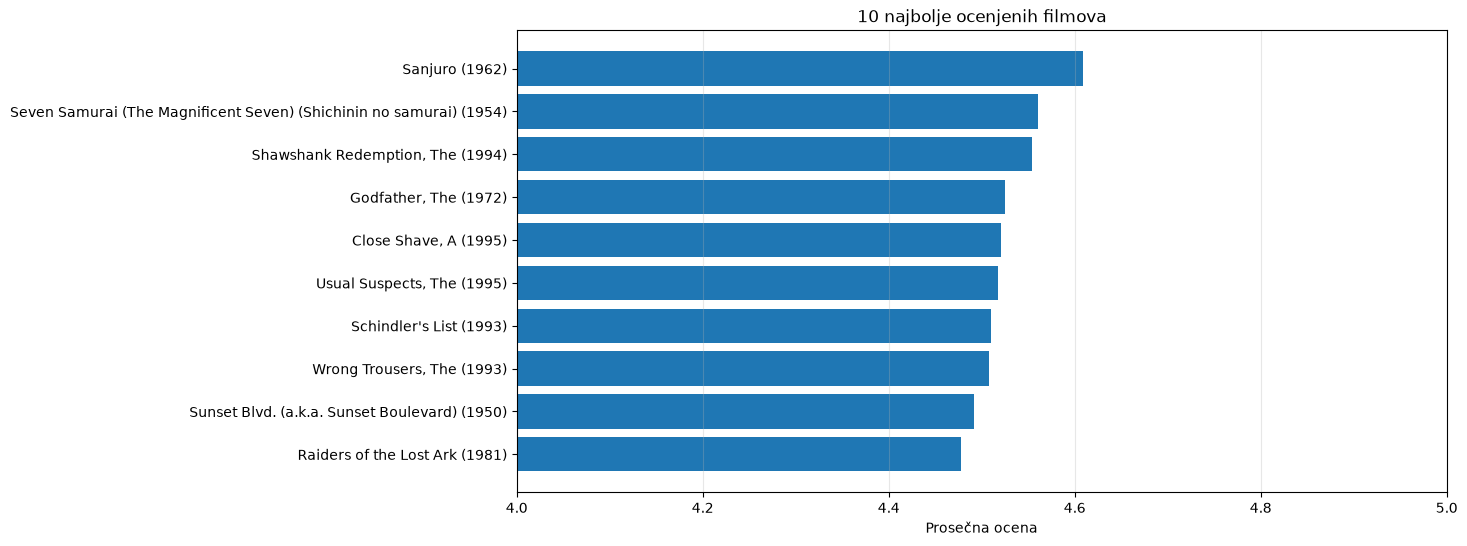

In [37]:
# Vizuelni prikaz najbolje ocenjenih filmova

plt.figure(figsize=(12,6))

plt.barh(
    top_rated_movies_pd["title"],
    top_rated_movies_pd["average_rating"]
)

plt.title("10 najbolje ocenjenih filmova")

plt.xlabel("Prosečna ocena")

plt.xlim(4,5)

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.show()

### Zaključak

Rezultati pokazuju da filmovi sa najvećom prosečnom ocenom nisu nužno i filmovi sa najvećim brojem ocena.

Uvođenjem minimalnog broja ocena izbegava se da filmovi sa malim brojem korisničkih ocena zauzmu vrh liste samo zbog jedne ili nekoliko visokih ocena.

> **Zanimljivost**

> IMDb koristi sličan princip prilikom formiranja liste najbolje ocenjenih filmova. Film mora imati dovoljan broj korisničkih ocena kako bi mogao da se nađe među najbolje ocenjenim naslovima.

## 4.7 Najzastupljeniji filmski žanrovi

Jedan film može pripadati većem broju žanrova. U MovieLens skupu žanrovi su sačuvani u obliku jednog tekstualnog polja, pri čemu su pojedinačne vrednosti razdvojene znakom `|`.

U ovom koraku žanrovi će biti razdvojeni, a zatim će biti izračunat broj filmova koji pripada svakom žanru.

In [38]:
from pyspark.sql.functions import split, explode, col, desc

In [39]:
# Razdvajanje žanrova i kreiranje posebnog reda za svaki žanr

movie_genres = (
    movies_df
    .select(
        "movieId",
        explode(split(col("genres"), r"\|")).alias("genre")
    )
)

movie_genres.show(10, truncate=False)

+-------+----------+
|movieId|genre     |
+-------+----------+
|1      |Animation |
|1      |Children's|
|1      |Comedy    |
|2      |Adventure |
|2      |Children's|
|2      |Fantasy   |
|3      |Comedy    |
|3      |Romance   |
|4      |Comedy    |
|4      |Drama     |
+-------+----------+
only showing top 10 rows


In [40]:
# Brojanje filmova po žanru

genre_distribution = (
    movie_genres
    .groupBy("genre")
    .count()
    .orderBy(desc("count"))
)

genre_distribution.show(truncate=False)

+-----------+-----+
|genre      |count|
+-----------+-----+
|Drama      |1603 |
|Comedy     |1200 |
|Action     |503  |
|Thriller   |492  |
|Romance    |471  |
|Horror     |343  |
|Adventure  |283  |
|Sci-Fi     |276  |
|Children's |251  |
|Crime      |211  |
|War        |143  |
|Documentary|127  |
|Musical    |114  |
|Mystery    |106  |
|Animation  |105  |
|Fantasy    |68   |
|Western    |68   |
|Film-Noir  |44   |
+-----------+-----+



In [41]:
# Priprema 10 najzastupljenijih žanrova za vizuelizaciju

top_genres_pd = (
    genre_distribution
    .limit(10)
    .toPandas()
)

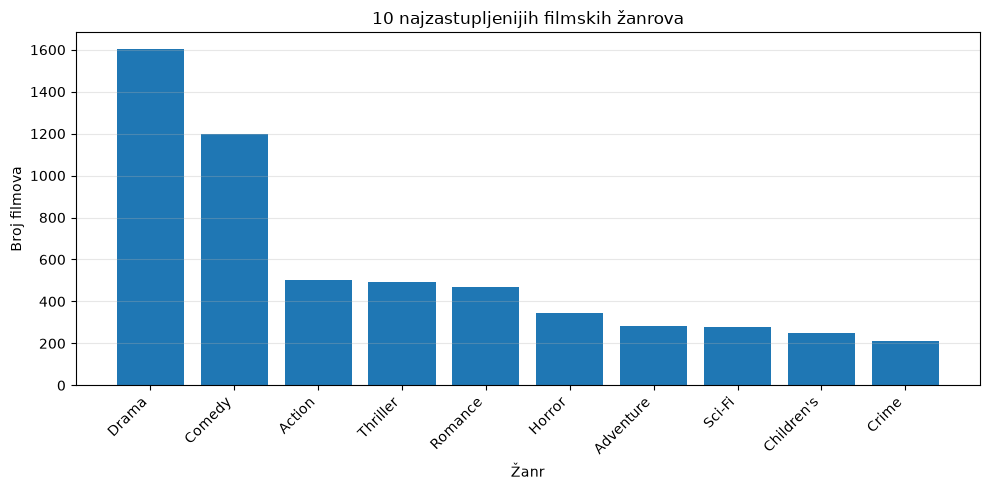

In [42]:
# Vizuelni prikaz najzastupljenijih žanrova

plt.figure(figsize=(10, 5))

plt.bar(
    top_genres_pd["genre"],
    top_genres_pd["count"]
)

plt.title("10 najzastupljenijih filmskih žanrova")
plt.xlabel("Žanr")
plt.ylabel("Broj filmova")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Zaključak

Grafikon prikazuje žanrove koji se najčešće pojavljuju u MovieLens skupu podataka.

Film može pripadati većem broju žanrova, zbog čega ukupan zbir prikazanih vrednosti može biti veći od ukupnog broja filmova.

> **Ključni zaključak**
>
> Zastupljenost žanrova nije ravnomerna. Žanrovi sa većim brojem filmova i ocena mogu imati veći uticaj na rezultate sistema preporuke, dok manje zastupljeni žanrovi predstavljaju izazov zbog manje količine dostupnih podataka.

## 4.8 Broj filmova po godinama

U MovieLens skupu podataka godina izlaska filma nije sačuvana kao posebno polje, već se nalazi u okviru naziva filma.

U ovom koraku godina će biti izdvojena iz naslova filma korišćenjem regularnog izraza, nakon čega će biti analizirana raspodela filmova po godinama.

In [43]:
# Izdvajanje godine iz naziva filma

movies_with_year = (
    movies_df
    .withColumn(
        "year",
        regexp_extract(
            col("title"),
            r"\((\d{4})\)",
            1
        )
    )
)

In [44]:
# Prikaz prvih nekoliko filmova sa izdvojenom godinom

movies_with_year.select(
    "title",
    "year"
).show(10, truncate=False)

+----------------------------------+----+
|title                             |year|
+----------------------------------+----+
|Toy Story (1995)                  |1995|
|Jumanji (1995)                    |1995|
|Grumpier Old Men (1995)           |1995|
|Waiting to Exhale (1995)          |1995|
|Father of the Bride Part II (1995)|1995|
|Heat (1995)                       |1995|
|Sabrina (1995)                    |1995|
|Tom and Huck (1995)               |1995|
|Sudden Death (1995)               |1995|
|GoldenEye (1995)                  |1995|
+----------------------------------+----+
only showing top 10 rows


In [45]:
# Broj filmova po godinama

movies_per_year = (
    movies_with_year
    .groupBy("year")
    .count()
    .filter(col("year") != "")
    .orderBy("year")
)

movies_per_year.show()

+----+-----+
|year|count|
+----+-----+
|1919|    3|
|1920|    2|
|1921|    1|
|1922|    2|
|1923|    3|
|1925|    6|
|1926|    8|
|1927|    6|
|1928|    3|
|1929|    3|
|1930|    7|
|1931|    7|
|1932|    7|
|1933|    7|
|1934|    7|
|1935|    6|
|1936|    8|
|1937|   11|
|1938|    6|
|1939|   11|
+----+-----+
only showing top 20 rows


In [46]:
# Konverzija u Pandas DataFrame

movies_per_year_pd = movies_per_year.toPandas()

movies_per_year_pd["year"] = (
    movies_per_year_pd["year"]
    .astype(int)
)

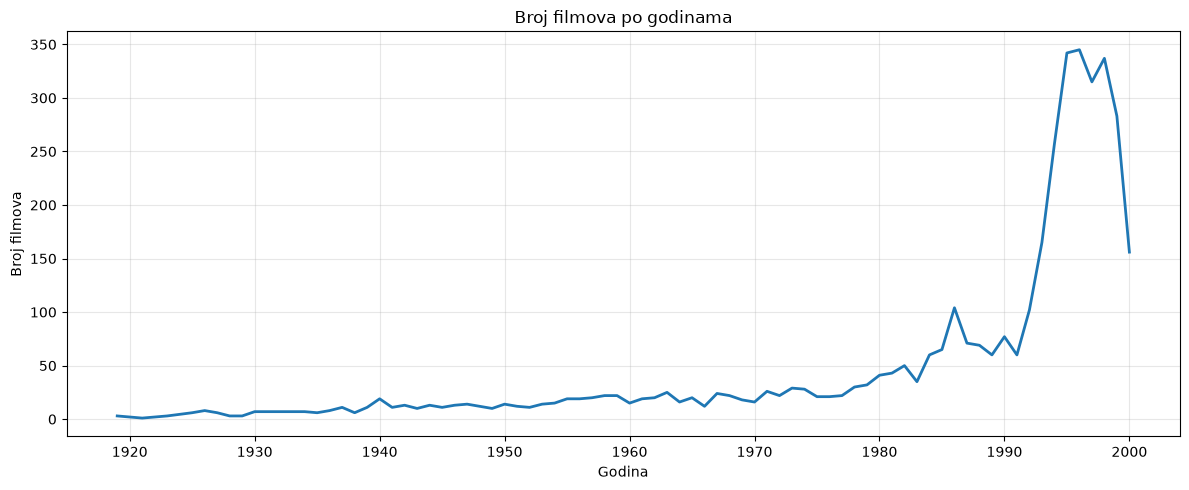

In [47]:
# Vizuelni prikaz broja filmova po godinama

plt.figure(figsize=(12,5))

plt.plot(
    movies_per_year_pd["year"],
    movies_per_year_pd["count"],
    linewidth=2
)

plt.title("Broj filmova po godinama")

plt.xlabel("Godina")

plt.ylabel("Broj filmova")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Zaključak

Na osnovu grafikona može se uočiti da broj filmova u MovieLens skupu nije ravnomerno raspoređen po godinama.

Najveći broj filmova potiče iz druge polovine XX veka, što odgovara periodu najveće produkcije filmova zastupljenih u MovieLens bazi.

> **Ključni zaključak**
>
> Analiza pokazuje da skup podataka nije vremenski ravnomerno raspoređen. Ova karakteristika može uticati na sistem preporuke, jer filmovi iz određenih perioda imaju znatno više ocena i veći broj korisničkih interakcija.

## 4.9 Aktivnost korisnika

Za kvalitet sistema preporuke veoma je važna količina podataka koju posedujemo o svakom korisniku.

U ovom delu analizira se broj ocena koje je dao svaki korisnik, kao i raspodela aktivnosti korisnika u okviru MovieLens skupa podataka.

In [48]:
# Broj ocena po korisniku

user_activity = (
    ratings_df
    .groupBy("userId")
    .count()
    .withColumnRenamed(
        "count",
        "number_of_ratings"
    )
)

user_activity.show()

+------+-----------------+
|userId|number_of_ratings|
+------+-----------------+
|   148|              624|
|   463|              123|
|   471|              105|
|   496|              119|
|   833|               21|
|  1088|             1176|
|  1238|               45|
|  1342|               92|
|  1580|               37|
|  1591|              314|
|  1645|              522|
|  1829|               30|
|  1959|               61|
|  2122|              208|
|  2142|               77|
|  2366|               41|
|  2659|              161|
|   243|               33|
|   392|              487|
|   540|               39|
+------+-----------------+
only showing top 20 rows


In [49]:
# Osnovna statistika aktivnosti korisnika

user_activity.describe().show()

+-------+------------------+------------------+
|summary|            userId| number_of_ratings|
+-------+------------------+------------------+
|  count|              6041|              6041|
|   mean| 3021.000165535507|165.57043535838437|
| stddev|1744.0311064214175|  192.742565965743|
|    min|                 1|                 2|
|    max|              6042|              2314|
+-------+------------------+------------------+



In [50]:
# Konverzija u Pandas DataFrame

user_activity_pd = user_activity.toPandas()

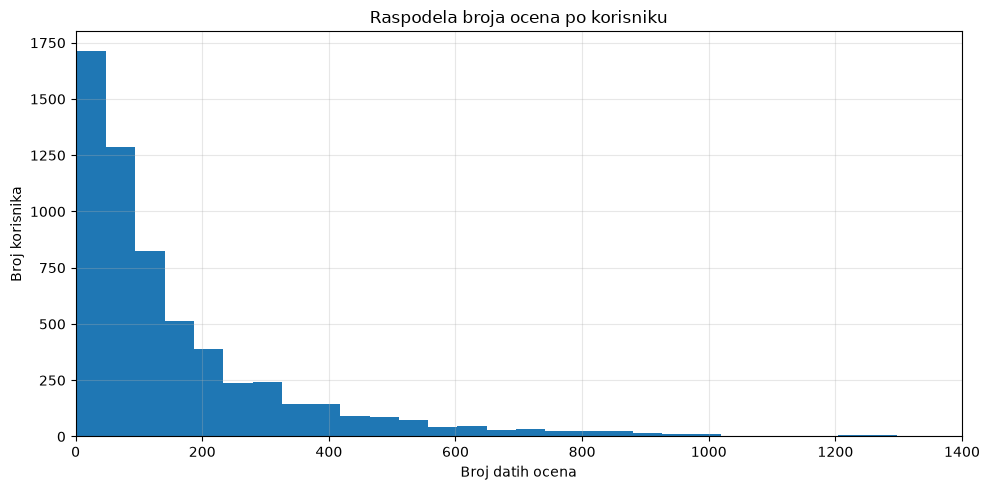

In [51]:
# Raspodela aktivnosti korisnika

plt.figure(figsize=(10,5))

plt.hist(
    user_activity_pd["number_of_ratings"],
    bins=50
)

plt.title("Raspodela broja ocena po korisniku")

plt.xlabel("Broj datih ocena")

plt.ylabel("Broj korisnika")

plt.xlim(0, 1400)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [52]:
summary = user_activity_pd["number_of_ratings"].describe()

summary

count    6041.000000
mean      165.570435
std       192.742566
min         2.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
Name: number_of_ratings, dtype: float64

### Zaključak

Na osnovu raspodele može se uočiti da većina korisnika daje relativno mali broj ocena, dok mali broj korisnika ocenjuje veliki broj filmova.

Takva raspodela je karakteristična za sisteme preporuke i predstavlja izazov prilikom treniranja modela.

> **Zanimljivost**
>
> Korisnici koji imaju veoma mali broj ocena predstavljaju jedan od najvećih izazova u sistemima preporuke. Ovaj problem poznat je pod nazivom **cold-start problem**, jer sistem raspolaže sa veoma malo informacija na osnovu kojih može da generiše kvalitetne preporuke.

## 4.10 Odnos broja ocena i prosečne ocene filma

Prilikom analize filmova nije dovoljno posmatrati samo prosečnu ocenu ili samo broj korisničkih ocena.

U ovom delu analizira se odnos između broja ocena koje je film dobio i njegove prosečne ocene.

Na ovaj način može se uočiti da filmovi sa malim brojem ocena često imaju veoma visoke prosečne ocene, dok popularni filmovi imaju stabilnije i reprezentativnije proseke.

In [53]:
movie_statistics.show()

+-------+------------------+-----------------+
|movieId|    average_rating|number_of_ratings|
+-------+------------------+-----------------+
|   1580| 3.739952718676123|             2538|
|   2366|3.6560846560846563|              756|
|   1088|3.3114992721979624|              687|
|   1959|3.6533546325878596|              626|
|   3175| 3.771412037037037|             1728|
|   1645|3.4358353510895885|              826|
|   2142|2.8308457711442787|              201|
|   1591|2.6210526315789475|              475|
|   2122|2.4463519313304722|              233|
|    833|2.1794871794871793|               78|
|    471| 3.631051752921536|              599|
|   1342| 2.904580152671756|              262|
|   3918| 2.802395209580838|              167|
|   3794|  3.28099173553719|              121|
|   1238|               4.0|              351|
|   2866|3.6884422110552766|              199|
|   1721|3.5834411384217333|             1546|
|   1084| 4.096209912536443|              686|
|   1127|3.68

In [54]:
# Konverzija u Pandas DataFrame

movie_statistics_pd = movie_statistics.toPandas()

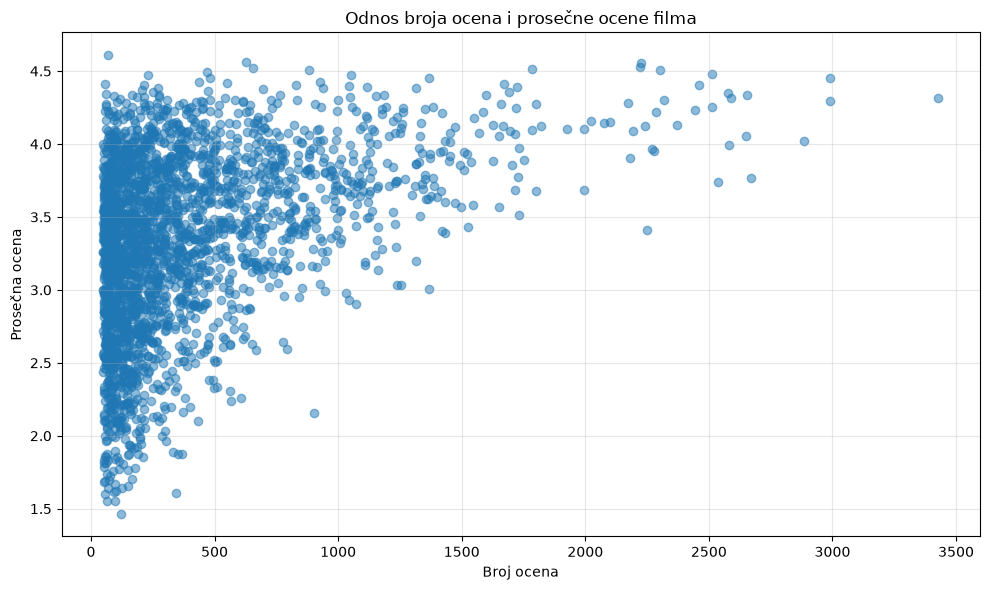

In [55]:
# Odnos broja ocena i prosečne ocene

plt.figure(figsize=(10,6))

plt.scatter(
    movie_statistics_pd["number_of_ratings"],
    movie_statistics_pd["average_rating"],
    alpha=0.5
)

plt.title("Odnos broja ocena i prosečne ocene filma")

plt.xlabel("Broj ocena")

plt.ylabel("Prosečna ocena")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [56]:
movie_statistics_pd[
    ["average_rating", "number_of_ratings"]
].describe()

,average_rating,number_of_ratings
count,2514.000000,2514.000000
mean,3.344114,388.958234
std,0.599117,416.236798
min,1.466667,50.000000
25%,2.945503,119.000000
50%,3.418258,238.000000
75%,3.805082,493.000000
max,4.608696,3428.000000


### Zaključak

Rezultati pokazuju da filmovi sa malim brojem ocena često imaju veoma visoke prosečne ocene.

Sa druge strane, filmovi koji imaju veliki broj korisničkih ocena uglavnom imaju stabilnije prosečne ocene, zbog čega predstavljaju pouzdaniju osnovu za analizu i preporuku.

> **Ključni zaključak**
>
> Analiza potvrđuje da broj korisničkih ocena predstavlja važan faktor pri proceni kvaliteta filma. Zbog toga se u sistemima preporuke i rangiranja često kombinuju informacije o prosečnoj oceni i broju ocena kako bi se dobili pouzdaniji rezultati.

## 4.11 Retkost korisničko-filmske matrice

Sistemi preporuke zasnivaju se na matrici korisnika i filmova, pri čemu svaki element matrice predstavlja ocenu koju je određeni korisnik dodelio određenom filmu.

U praksi većina korisnika ocenjuje samo mali broj filmova, zbog čega najveći deo matrice ostaje nepopunjen.

U ovom koraku izračunava se gustina (*density*) i retkost (*sparsity*) korisničko-filmske matrice.

In [57]:
# Broj korisnika

number_of_users = ratings_df.select("userId").distinct().count()

# Broj filmova

number_of_movies = ratings_df.select("movieId").distinct().count()

# Broj postojećih ocena

number_of_ratings = ratings_df.count()

# Ukupan broj mogućih ocena

possible_ratings = number_of_users * number_of_movies

# Gustina matrice

density = number_of_ratings / possible_ratings

# Retkost matrice

sparsity = 1 - density

In [58]:
import pandas as pd

summary = pd.DataFrame({

    "Pokazatelj": [

        "Broj korisnika",

        "Broj filmova",

        "Broj postojećih ocena",

        "Ukupan broj mogućih ocena",

        "Gustina matrice",

        "Retkost matrice"

    ],

    "Vrednost": [

        f"{number_of_users:,}",

        f"{number_of_movies:,}",

        f"{number_of_ratings:,}",

        f"{possible_ratings:,}",

        f"{density:.2%}",

        f"{sparsity:.2%}"

    ]

})

summary

,Pokazatelj,Vrednost
0,Broj korisnika,"6,041"
1,Broj filmova,"3,706"
2,Broj postojećih ocena,"1,000,211"
3,Ukupan broj mogućih ocena,"22,387,946"
4,Gustina matrice,4.47%
5,Retkost matrice,95.53%


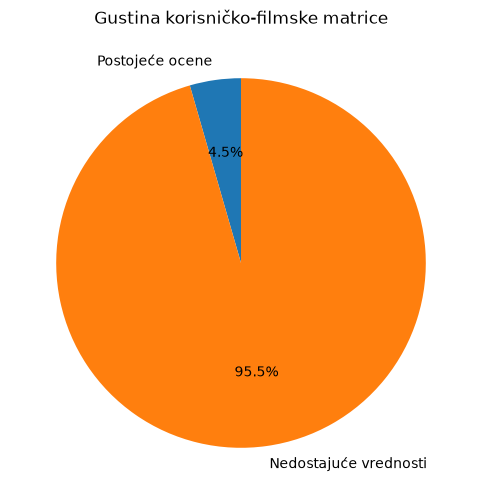

In [59]:
plt.figure(figsize=(6,6))

plt.pie(

    [density, sparsity],

    labels=["Postojeće ocene", "Nedostajuće vrednosti"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Gustina korisničko-filmske matrice")

plt.show()

### Zaključak

Dobijeni rezultati pokazuju da je korisničko-filmska matrica izrazito retka.

Većina mogućih korisnik–film kombinacija nema dodeljenu ocenu, što predstavlja tipičnu karakteristiku sistema preporuke zasnovanih na kolaborativnom filtriranju.

> **Ključni zaključak**
>
> Izrazita retkost korisničko-filmske matrice predstavlja jedan od osnovnih razloga za primenu ALS algoritma. Ovaj algoritam je razvijen upravo za rad sa velikim i retkim matricama i omogućava predviđanje ocena koje korisnici još uvek nisu dodelili filmovima.

# Zaključak eksplorativne analize

Izvršena analiza omogućila je detaljan uvid u karakteristike MovieLens skupa podataka.

Utvrđeno je da korisnici najčešće dodeljuju više ocene, dok je broj ocena po korisniku i po filmu neravnomerno raspoređen. Takođe, uočeno je da popularnost filma nije direktno povezana sa njegovom prosečnom ocenom, zbog čega se prilikom analize moraju posmatrati oba kriterijuma.

Analiza je pokazala i da je korisničko-filmska matrica izrazito retka, odnosno da najveći deo mogućih korisnik–film kombinacija nema dodeljenu ocenu. Ovakva struktura predstavlja tipičnu karakteristiku sistema preporuke zasnovanih na kolaborativnom filtriranju.

Na osnovu dobijenih rezultata može se zaključiti da MovieLens skup podataka predstavlja odgovarajuću osnovu za primenu ALS algoritma, koji je namenjen radu sa velikim i retkim matricama korisničkih ocena.

# 5. Jednostavan sistem preporuke

Pre izgradnje personalizovanog sistema preporuke korisno je prikazati jednostavan pristup koji svim korisnicima preporučuje iste filmove.

U ovom primeru preporučuju se filmovi sa najboljom prosečnom ocenom, uz uslov da film ima najmanje 50 korisničkih ocena.

Ovakav pristup može ponuditi kvalitetne i popularne filmove, ali ne uzima u obzir individualna interesovanja korisnika.

In [60]:
# Formiranje nepersonalizovane liste preporuka

baseline_recommendations = (
    ratings_df
    .groupBy("movieId")
    .agg(
        avg("rating").alias("average_rating"),
        count("rating").alias("number_of_ratings")
    )
    .filter(col("number_of_ratings") >= 50)
    .join(
        movies_df.select(
            "movieId",
            "title",
            "genres"
        ),
        on="movieId",
        how="inner"
    )
    .orderBy(
        desc("average_rating"),
        desc("number_of_ratings")
    )
)

In [61]:
# Prikaz 10 opštih preporuka

baseline_recommendations.select(
    "title",
    "genres",
    "average_rating",
    "number_of_ratings"
).show(
    10,
    truncate=False
)

+-------------------------------------------------------------------+-------------------------+-----------------+-----------------+
|title                                                              |genres                   |average_rating   |number_of_ratings|
+-------------------------------------------------------------------+-------------------------+-----------------+-----------------+
|Sanjuro (1962)                                                     |Action|Adventure         |4.608695652173913|69               |
|Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)|Action|Drama             |4.560509554140127|628              |
|Shawshank Redemption, The (1994)                                   |Drama                    |4.554557700942973|2227             |
|Godfather, The (1972)                                              |Action|Crime|Drama       |4.524966261808367|2223             |
|Close Shave, A (1995)                                              |Animati

In [62]:
# Priprema rezultata za pregled u notebook-u

baseline_recommendations_pd = (
    baseline_recommendations
    .select(
        "title",
        "average_rating",
        "number_of_ratings"
    )
    .limit(10)
    .toPandas()
)

baseline_recommendations_pd["average_rating"] = (
    baseline_recommendations_pd["average_rating"].round(2)
)

baseline_recommendations_pd

,title,average_rating,number_of_ratings
0,Sanjuro (1962),4.61,69
1,Seven Samurai (The Magnificent Seven) (Shichin...,4.56,628
2,"Shawshank Redemption, The (1994)",4.55,2227
3,"Godfather, The (1972)",4.52,2223
4,"Close Shave, A (1995)",4.52,657
5,"Usual Suspects, The (1995)",4.52,1783
6,Schindler's List (1993),4.51,2304
7,"Wrong Trousers, The (1993)",4.51,882
8,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.49,470
9,Raiders of the Lost Ark (1981),4.48,2514


### Zaključak

Jednostavan sistem preporuke svim korisnicima prikazuje istu listu najbolje ocenjenih filmova.

Njegova prednost je jednostavnost, ali preporuke nisu personalizovane. Korisnik koji preferira komedije i korisnik koji preferira horor filmove dobiće potpuno iste rezultate.

Zbog toga je potrebno primeniti algoritam koji uči individualne preferencije korisnika na osnovu prethodno dodeljenih ocena.

> **Ključni zaključak**
>
> Popularni i visoko ocenjeni filmovi mogu predstavljati dobru početnu preporuku, ali nepersonalizovani pristup ne uzima u obzir razlike između korisnika. ALS model će omogućiti generisanje različitih preporuka za svakog korisnika.

# 6. Priprema podataka za treniranje ALS modela

ALS model koristi tri osnovna podatka:

- identifikator korisnika (`userId`),
- identifikator filma (`movieId`),
- korisničku ocenu (`rating`).

Pre treniranja potrebno je izabrati odgovarajuće kolone, proveriti njihove tipove, ukloniti neispravne zapise i rešiti eventualne duplikate.

In [63]:
# Pregled tipova kolona potrebnih za ALS model

ratings_df.select(
    "userId",
    "movieId",
    "rating"
).printSchema()

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: integer (nullable = true)



In [64]:
from pyspark.sql.types import IntegerType, FloatType

In [65]:
# Izbor potrebnih kolona i konverzija tipova

als_ratings_df = (
    ratings_df
    .select(
        col("userId").cast(IntegerType()).alias("userId"),
        col("movieId").cast(IntegerType()).alias("movieId"),
        col("rating").cast(FloatType()).alias("rating"),
        col("timestamp")
    )
)

In [66]:
# Uklanjanje zapisa sa nedostajućim vrednostima

als_ratings_df = (
    als_ratings_df
    .dropna(
        subset=[
            "userId",
            "movieId",
            "rating"
        ]
    )
    .filter(
        (col("rating") >= 1.0)
        & (col("rating") <= 5.0)
    )
)

In [67]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

In [68]:
# Definisanje redosleda ocena od najnovije ka najstarijoj

rating_window = (
    Window
    .partitionBy(
        "userId",
        "movieId"
    )
    .orderBy(
        col("timestamp").desc()
    )
)

In [69]:
# Zadržavanje najnovije ocene za svaki par korisnik-film

als_ratings_df = (
    als_ratings_df
    .withColumn(
        "row_number",
        row_number().over(rating_window)
    )
    .filter(
        col("row_number") == 1
    )
    .drop(
        "row_number"
    )
)

In [70]:
# Provera pripremljenih podataka

als_ratings_df.show(10, truncate=False)

als_ratings_df.printSchema()

print(
    "Broj ocena nakon pripreme:",
    als_ratings_df.count()
)

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |527    |5.0   |978824195|
|1     |938    |4.0   |978301752|
|1     |1022   |5.0   |978300055|
|1     |1029   |5.0   |978302205|
|1     |1207   |4.0   |978300719|
|1     |1246   |4.0   |978302091|
|1     |3408   |4.0   |978300275|
|2     |165    |3.0   |978300002|
|2     |982    |4.0   |978299269|
|2     |1213   |2.0   |978298458|
+------+-------+------+---------+
only showing top 10 rows
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: integer (nullable = true)

Broj ocena nakon pripreme: 1000211


In [71]:
# Završna provera duplikata

remaining_duplicates = (
    als_ratings_df
    .groupBy(
        "userId",
        "movieId"
    )
    .count()
    .filter(
        col("count") > 1
    )
    .count()
)

print(
    "Broj preostalih duplih korisnik-film parova:",
    remaining_duplicates
)

Broj preostalih duplih korisnik-film parova: 0


### Zaključak

Za treniranje ALS modela izdvojene su kolone `userId`, `movieId` i `rating`, a njihovi tipovi konvertovani su u odgovarajuće numeričke tipove.

Uklonjeni su zapisi sa nedostajućim ili neispravnim vrednostima. Za svaki par korisnik–film zadržana je samo najnovija ocena, čime su uklonjeni eventualni duplikati.

Pripremljeni podaci sada su spremni za podelu na trening i test skup.

## 6.1 Podela podataka na trening i test skup

Kako bi se objektivno procenila uspešnost sistema preporuke, raspoloživi podaci dele se na dva dela:

- **trening skup**, koji se koristi za obučavanje ALS modela,
- **test skup**, koji se koristi za proveru uspešnosti modela na podacima koje prethodno nije video.

U ovom radu koristi se podela **80% : 20%**, pri čemu se 80% ocena koristi za treniranje modela, a preostalih 20% za njegovu evaluaciju.

In [72]:
# Podela podataka na trening i test skup

train_df, test_df = als_ratings_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [73]:
# Broj zapisa u trening i test skupu

print("Training ratings:", train_df.count())

print("Test ratings:", test_df.count())

Training ratings: 800445
Test ratings: 199766


In [74]:
import pandas as pd

split_summary = pd.DataFrame({

    "Skup": [

        "Trening",

        "Test"

    ],

    "Broj ocena": [

        train_df.count(),

        test_df.count()

    ]

})

split_summary

,Skup,Broj ocena
0,Trening,800453
1,Test,199766


### Zaključak

Podaci su uspešno podeljeni na trening i test skup.

ALS model će biti obučen korišćenjem trening skupa, dok će se njegova uspešnost procenjivati na test skupu koji nije korišćen tokom procesa treniranja.

# 7. Treniranje ALS modela

Nakon pripreme podataka može se pristupiti treniranju sistema za preporuku.

Za izgradnju modela koristi se **ALS (Alternating Least Squares)** algoritam, koji predstavlja jedan od najpoznatijih algoritama za kolaborativno filtriranje.

ALS model pokušava da pronađe skrivene karakteristike korisnika i filmova na osnovu postojećih ocena, kako bi mogao da predvidi ocene koje korisnici još nisu dodelili.

In [75]:
# Kreiranje ALS modela

als = ALS(

    userCol="userId",

    itemCol="movieId",

    ratingCol="rating",

    coldStartStrategy="drop",

    nonnegative=True,

    implicitPrefs=False,

    rank=10,

    maxIter=10,

    regParam=0.1,

    seed=42

)

## 7.1 Izbor hiperparametara ALS modela

Performanse ALS algoritma zavise od izbora hiperparametara koji određuju način treniranja modela.

U ovom radu korišćene su vrednosti koje predstavljaju dobar početni izbor za MovieLens skup podataka i koje omogućavaju postizanje ravnoteže između tačnosti modela i vremena treniranja.

Kasnije će biti prikazan uticaj pojedinih hiperparametara na kvalitet preporuka.

In [76]:
import pandas as pd

als_parameters = pd.DataFrame({

    "Parametar": [

        "rank",

        "maxIter",

        "regParam",

        "nonnegative",

        "implicitPrefs",

        "coldStartStrategy"

    ],

    "Vrednost": [

        10,

        10,

        0.1,

        True,

        False,

        "drop"

    ],

    "Opis": [

        "Broj latentnih faktora",

        "Broj iteracija algoritma",

        "Parametar regularizacije",

        "Latentni faktori su nenegativni",

        "Koriste se eksplicitne ocene",

        "Uklanjanje NaN predikcija"

    ]

})

als_parameters

,Parametar,Vrednost,Opis
0,rank,10,Broj latentnih faktora
1,maxIter,10,Broj iteracija algoritma
2,regParam,0.1,Parametar regularizacije
3,nonnegative,True,Latentni faktori su nenegativni
4,implicitPrefs,False,Koriste se eksplicitne ocene
5,coldStartStrategy,drop,Uklanjanje NaN predikcija


### Objašnjenje hiperparametara

- **rank** određuje broj latentnih faktora kojima se opisuju korisnici i filmovi. Veći broj faktora može povećati tačnost modela, ali i vreme treniranja.

- **maxIter** predstavlja maksimalan broj iteracija ALS algoritma tokom optimizacije.

- **regParam** kontroliše regularizaciju modela i smanjuje mogućnost preprilagođavanja (*overfitting*).

- **nonnegative=True** obezbeđuje da latentni faktori imaju nenegativne vrednosti, što može doprineti stabilnijem modelu.

- **implicitPrefs=False** označava da model koristi eksplicitne korisničke ocene, a ne implicitne informacije poput broja pregleda ili klikova.

- **coldStartStrategy="drop"** uklanja predikcije koje nije moguće izračunati za korisnike ili filmove koji nisu viđeni tokom treniranja.

In [77]:
# Kreiranje ALS modela

als = ALS(

    userCol="userId",

    itemCol="movieId",

    ratingCol="rating",

    rank=10,

    maxIter=10,

    regParam=0.1,

    implicitPrefs=False,

    nonnegative=True,

    coldStartStrategy="drop",

    seed=42

)

## 7.2 Treniranje modela

Nakon definisanja hiperparametara pristupa se treniranju ALS modela korišćenjem trening skupa.

Tokom procesa treniranja algoritam izračunava latentne karakteristike korisnika i filmova koje će kasnije biti korišćene za predviđanje novih ocena.

In [78]:
# Treniranje ALS modela

model = als.fit(train_df)

In [79]:
print("ALS model je uspešno istreniran.")

ALS model je uspešno istreniran.


## 7.3 Latentni faktori korisnika i filmova

Nakon treniranja modela ALS algoritam ne pamti pojedinačne ocene korisnika, već za svakog korisnika i svaki film određuje skup skrivenih karakteristika, poznatih kao **latentni faktori**.

Latentni faktori predstavljaju numeričke vektore koji opisuju karakteristike korisnika i filmova u prostoru manjih dimenzija.

Na osnovu ovih vektora model procenjuje koliko će se određeni korisnik verovatno dopasti određenom filmu, čak i ukoliko taj film prethodno nije ocenio.

In [80]:
# Prikaz latentnih faktora korisnika

model.userFactors.show(10, truncate=False)

+---+----------------------------------------------------------------------------------------------------------------------+
|id |features                                                                                                              |
+---+----------------------------------------------------------------------------------------------------------------------+
|10 |[0.57283086, 0.817167, 0.118358895, 1.5465384, 1.5589505, 0.26994455, 0.55595654, 0.61228323, 0.93231136, 0.5674229]  |
|20 |[0.43377218, 0.14938222, 0.7330441, 1.5476749, 1.1278391, 0.33528775, 0.6209006, 0.6491493, 0.6910565, 1.1269931]     |
|30 |[0.8579169, 0.27257165, 0.9453476, 1.2646109, 1.0319954, 0.0, 0.0, 0.2573941, 0.4664981, 0.83672726]                  |
|40 |[0.38999242, 0.4219173, 0.6841978, 1.0728831, 1.3048308, 0.06436793, 0.7561601, 0.78729826, 0.2656185, 0.69758785]    |
|50 |[0.39555356, 0.73644674, 0.8237663, 1.1610221, 1.0957333, 0.29575372, 0.3367638, 0.4751513, 0.5794434, 0.48997527]    |


In [81]:
# Prikaz latentnih faktora filmova

model.itemFactors.show(10, truncate=False)

+---+----------------------------------------------------------------------------------------------------------------------+
|id |features                                                                                                              |
+---+----------------------------------------------------------------------------------------------------------------------+
|10 |[0.0, 0.04277941, 0.11710507, 0.86351734, 0.8538426, 0.0, 0.3361049, 0.23527773, 0.43093133, 0.66090137]              |
|20 |[0.07591828, 0.0581548, 0.13109046, 0.4564335, 0.7688971, 0.0, 0.0, 0.0, 0.5399362, 0.4753462]                        |
|30 |[0.5089133, 0.40849048, 0.70322305, 0.18697156, 0.5974155, 0.68470585, 0.7245293, 0.46968603, 0.757942, 0.11582269]   |
|40 |[0.4643037, 0.58534926, 0.48622602, 0.85208887, 0.41114023, 0.29498827, 0.95318174, 0.40947032, 0.452982, 0.0]        |
|50 |[0.24044015, 0.24204749, 0.790723, 1.223951, 0.65557843, 0.22745967, 0.46987757, 0.37244907, 0.24682176, 0.626194]    |


### Objašnjenje

Svaki korisnik i svaki film predstavljeni su vektorom latentnih faktora.

Vrednosti u ovim vektorima nemaju direktno značenje poput "voli akcione filmove" ili "preferira komedije". Umesto toga, model tokom treniranja sam pronalazi obrasce u ocenama korisnika i formira matematičku reprezentaciju njihovih preferencija i karakteristika filmova.

Slični korisnici imaju slične latentne faktore, dok filmovi koje korisnici ocenjuju na sličan način takođe dobijaju slične reprezentacije.

> **Zanimljivost**
>
> ALS ne koristi informacije poput naziva filma, žanra ili godine izlaska. Model uči isključivo iz korisničkih ocena i na osnovu njih otkriva skrivene obrasce koji omogućavaju generisanje personalizovanih preporuka.

## 7.4 Predviđanje korisničkih ocena

Nakon treniranja model koristi naučene latentne faktore kako bi procenio ocene koje korisnici još nisu dodelili filmovima.

U ovom koraku model generiše predviđene ocene za test skup, odnosno za podatke koji nisu korišćeni tokom treniranja.

In [82]:
# Generisanje predikcija na test skupu

predictions = model.transform(test_df)

In [83]:
# Prikaz prvih predikcija

predictions.select(
    "userId",
    "movieId",
    "rating",
    "prediction"
).show(10)

+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|     1|   1022|   5.0| 4.1178503|
|     1|   3408|   4.0| 4.0142503|
|     2|    982|   4.0| 3.3734028|
|     2|   3035|   4.0|  3.939262|
|     3|   3671|   5.0| 3.7551858|
|     5|    272|   3.0|  3.208003|
|     5|   1610|   4.0| 2.5095627|
|     5|   3176|   2.0|  3.042279|
|     8|    150|   4.0| 3.9926858|
|     8|    151|   4.0| 3.6992204|
+------+-------+------+----------+
only showing top 10 rows


### Objašnjenje

Kolona **rating** predstavlja stvarnu ocenu koju je korisnik dodelio filmu.

Kolona **prediction** predstavlja ocenu koju je ALS model predvideo koristeći latentne faktore korisnika i filmova.

Što je razlika između ove dve vrednosti manja, model je uspešniji.

In [84]:
# Prikaz predikcija sa zaokruženim vrednostima
from pyspark.sql.functions import round
predictions.select(
    "userId",
    "movieId",
    "rating",
    round(col("prediction"), 2).alias("prediction")
).show(10)

+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|     1|   1022|   5.0|      4.12|
|     1|   3408|   4.0|      4.01|
|     2|    982|   4.0|      3.37|
|     2|   3035|   4.0|      3.94|
|     3|   3671|   5.0|      3.76|
|     5|    272|   3.0|      3.21|
|     5|   1610|   4.0|      2.51|
|     5|   3176|   2.0|      3.04|
|     8|    150|   4.0|      3.99|
|     8|    151|   4.0|       3.7|
+------+-------+------+----------+
only showing top 10 rows


> **Ključni zaključak**
>
> Za razliku od originalnih korisničkih ocena, koje imaju unapred definisane vrednosti, ALS model generiše realne brojeve koji predstavljaju procenu koliko bi se određeni film mogao dopasti korisniku.

# 8. Evaluacija ALS modela

Kako bi se procenio kvalitet sistema preporuke, potrebno je uporediti predviđene ocene sa stvarnim korisničkim ocenama.

U ovom radu kao mera uspešnosti koristi se **RMSE (Root Mean Squared Error)**, koja predstavlja jednu od najčešće korišćenih metrika za evaluaciju sistema preporuke zasnovanih na eksplicitnim ocenama.

Manja vrednost RMSE ukazuje na preciznije predviđanje korisničkih ocena.

## 8.1 Analiza uticaja hiperparametra *rank*

Jedan od najvažnijih hiperparametara ALS algoritma jeste **rank**, koji određuje broj latentnih faktora korišćenih za opis korisnika i filmova.

Mala vrednost može dovesti do nedovoljnog opisivanja korisničkih preferencija, dok prevelika vrednost povećava složenost modela i može dovesti do preprilagođavanja.

U ovom delu ispituje se uticaj različitih vrednosti parametra **rank** na tačnost modela korišćenjem RMSE metrike.

In [85]:
from pyspark.ml.evaluation import RegressionEvaluator

In [86]:
# Evaluator za RMSE

evaluator = RegressionEvaluator(

    metricName="rmse",

    labelCol="rating",

    predictionCol="prediction"

)

In [87]:
# Vrednosti hiperparametra koje će biti testirane

ranks = [5, 10, 15, 20, 25]

In [88]:
results = []

for rank in ranks:

    als = ALS(

        userCol="userId",

        itemCol="movieId",

        ratingCol="rating",

        rank=rank,

        maxIter=10,

        regParam=0.1,

        coldStartStrategy="drop",

        implicitPrefs=False,

        nonnegative=True,

        seed=42

    )

    model = als.fit(train_df)

    predictions = model.transform(test_df)

    rmse = evaluator.evaluate(predictions)

    results.append(

        (rank, rmse)

    )

    print(f"Rank = {rank} | RMSE = {rmse:.4f}")

Rank = 5 | RMSE = 0.8787
Rank = 10 | RMSE = 0.8760
Rank = 15 | RMSE = 0.8721
Rank = 20 | RMSE = 0.8702
Rank = 25 | RMSE = 0.8500


In [89]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Rank",

        "RMSE"

    ]

)

results_df

,Rank,RMSE
0,5,0.878685
1,10,0.876046
2,15,0.872073
3,20,0.870237
4,25,0.849975


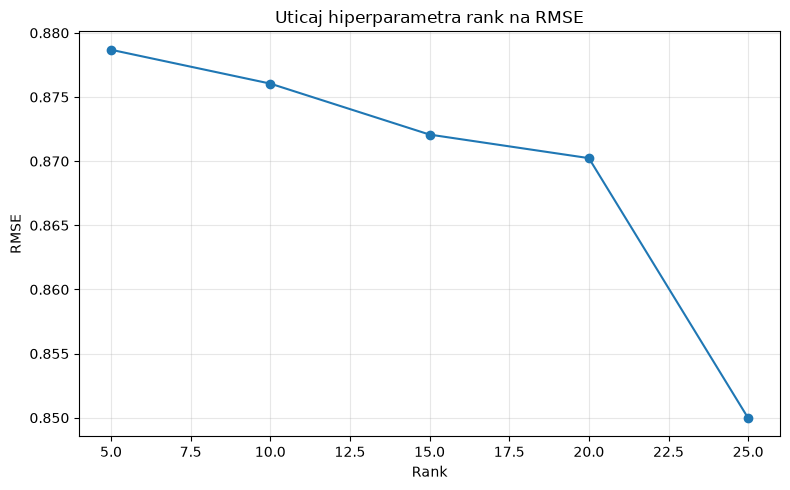

In [90]:
plt.figure(figsize=(8,5))

plt.plot(

    results_df["Rank"],

    results_df["RMSE"],

    marker="o"

)

plt.title("Uticaj hiperparametra rank na RMSE")

plt.xlabel("Rank")

plt.ylabel("RMSE")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Zaključak

Na osnovu rezultata može se uočiti kako promena broja latentnih faktora utiče na tačnost ALS modela.

Optimalna vrednost parametra **rank** odgovara najmanjoj vrednosti RMSE, zbog čega će upravo ta vrednost biti korišćena u nastavku rada.

> **Ključni zaključak**
>
> Izbor hiperparametara značajno utiče na kvalitet sistema preporuke. Eksperimentalnim ispitivanjem različitih vrednosti parametra **rank** moguće je pronaći konfiguraciju koja daje najtačnije predikcije.

## 8.2 Izbor najboljeg modela

Nakon treniranja ALS modela sa različitim vrednostima hiperparametra `rank`, bira se konfiguracija koja je ostvarila najmanju RMSE vrednost.

Izabrana vrednost koristi se za treniranje konačnog modela nad trening skupom.

In [91]:
# Pronalaženje vrednosti parametra rank sa najmanjim RMSE rezultatom

best_result = min(
    results,
    key=lambda result: result[1]
)

best_rank = best_result[0]
best_rank_rmse = best_result[1]

print(f"Najbolji rank: {best_rank}")
print(f"RMSE za najbolji rank: {best_rank_rmse:.4f}")

Najbolji rank: 25
RMSE za najbolji rank: 0.8500


In [92]:
# Kreiranje konačnog ALS modela sa najboljim rank parametrom

final_als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=best_rank,
    maxIter=10,
    regParam=0.1,
    implicitPrefs=False,
    nonnegative=True,
    coldStartStrategy="drop",
    seed=42
)

In [93]:
# Treniranje konačnog ALS modela

final_model = final_als.fit(train_df)

print("Konačni ALS model je uspešno istreniran.")

Konačni ALS model je uspešno istreniran.


## 8.3 Konačna evaluacija modela

Konačni model evaluira se nad test skupom koji nije korišćen tokom treniranja.

RMSE meri prosečnu veličinu greške između stvarnih korisničkih ocena i vrednosti koje je model predvideo. Manja RMSE vrednost označava precizniji model.

In [94]:
# Generisanje predikcija konačnog modela

final_predictions = final_model.transform(test_df)

In [96]:
# Broj test zapisa za koje je model generisao predikciju
# ovo je korisno iako smo stavili coldStartStrategy="drop" i na taj nacin uklonili predikcije za nepoznate korisnike ili filmove

test_count = test_df.count()
prediction_count = final_predictions.count()

print(f"Ukupan broj ocena u test skupu: {test_count}")
print(f"Broj evaluiranih predikcija: {prediction_count}")
print(f"Broj odbačenih cold-start zapisa: {test_count - prediction_count}")

Ukupan broj ocena u test skupu: 199766
Broj evaluiranih predikcija: 199725
Broj odbačenih cold-start zapisa: 41


In [97]:
# Izračunavanje konačne RMSE vrednosti

final_rmse = evaluator.evaluate(final_predictions)

print(f"Konačni RMSE: {final_rmse:.4f}")

Konačni RMSE: 0.8697


In [111]:
from pyspark.sql.functions import round as spark_round #za spark kolone

In [105]:
# Poređenje stvarnih i predviđenih ocena

final_predictions.select(
    "userId",
    "movieId",
    "rating",
    spark_round(
        col("prediction"),
        2
    ).alias("prediction")
).show(
    15,
    truncate=False
)

+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|1     |1022   |5.0   |4.09      |
|1     |3408   |4.0   |4.05      |
|2     |982    |4.0   |3.28      |
|2     |3035   |4.0   |3.95      |
|3     |3671   |5.0   |3.77      |
|5     |272    |3.0   |3.27      |
|5     |1610   |4.0   |2.5       |
|5     |3176   |2.0   |3.03      |
|8     |150    |4.0   |4.0       |
|8     |151    |4.0   |3.65      |
|8     |161    |3.0   |3.69      |
|8     |506    |3.0   |3.54      |
|8     |908    |5.0   |4.31      |
|8     |1660   |3.0   |3.64      |
|9     |720    |4.0   |4.06      |
+------+-------+------+----------+
only showing top 15 rows


In [110]:
# za obicne brojeve
import builtins

In [109]:
final_model_summary = pd.DataFrame({
    "Pokazatelj": [
        "Rank",
        "Broj iteracija",
        "Parametar regularizacije",
        "Broj trening ocena",
        "Broj test ocena",
        "Broj evaluiranih predikcija",
        "RMSE"
    ],
    "Vrednost": [
        best_rank,
        10,
        0.1,
        train_df.count(),
        test_count,
        prediction_count,
        builtins.round(final_rmse, 4)
    ]
})

final_model_summary

,Pokazatelj,Vrednost
0,Rank,25.0000
1,Broj iteracija,10.0000
2,Parametar regularizacije,0.1000
3,Broj trening ocena,800445.0000
4,Broj test ocena,199766.0000
5,Broj evaluiranih predikcija,199725.0000
6,RMSE,0.8697


### Zaključak

Eksperimentalnim ispitivanjem različitih vrednosti parametra `rank` izabrana je konfiguracija koja ostvaruje najmanju RMSE vrednost.

Konačni model obučen je korišćenjem izabrane vrednosti i evaluiran nad izdvojenim test skupom. Dobijeni RMSE predstavlja prosečno odstupanje predviđenih ocena od stvarnih korisničkih ocena.

> **Ključni zaključak**
>
> Konačni ALS model nije izabran proizvoljno, već na osnovu eksperimentalnog poređenja više konfiguracija. Time se dobija pouzdanija osnova za generisanje personalizovanih preporuka.

# 9. Generisanje personalizovanih preporuka

Konačni cilj sistema preporuke jeste generisanje liste filmova koji bi se mogli dopasti konkretnom korisniku.

U ovom delu biće prikazane preporuke generisane ALS modelom za jednog korisnika iz MovieLens skupa podataka, kao i poređenje sa filmovima koje je taj korisnik prethodno visoko ocenio.

## 9.1 Filmovi koje je korisnik visoko ocenio

Pre prikaza preporuka korisno je analizirati koje je filmove korisnik prethodno ocenio visokim ocenama.

Na osnovu toga može se lakše proceniti kvalitet generisanih preporuka.

In [113]:
selected_user = 1

In [114]:
# Filmovi koje je korisnik ocenio ocenom 4 ili više

favorite_movies = (

    ratings_df

    .filter(

        (col("userId") == selected_user)

        &

        (col("rating") >= 4)

    )

    .join(

        movies_df,

        on="movieId"

    )

    .select(

        "title",

        "genres",

        "rating"

    )

    .orderBy(

        desc("rating")

    )

)

In [115]:
favorite_movies.show(
    10,
    truncate=False
)

+--------------------------+----------------------------+------+
|title                     |genres                      |rating|
+--------------------------+----------------------------+------+
|Toy Story (1995)          |Animation|Children's|Comedy |5     |
|Saving Private Ryan (1998)|Action|Drama|War            |5     |
|Mary Poppins (1964)       |Children's|Comedy|Musical   |5     |
|Back to the Future (1985) |Comedy|Sci-Fi               |5     |
|Dumbo (1941)              |Animation|Children's|Musical|5     |
|Sound of Music, The (1965)|Musical                     |5     |
|Cinderella (1950)         |Animation|Children's|Musical|5     |
|Bug's Life, A (1998)      |Animation|Children's|Comedy |5     |
|Ben-Hur (1959)            |Action|Adventure|Drama      |5     |
|Rain Man (1988)           |Drama                       |5     |
+--------------------------+----------------------------+------+
only showing top 10 rows


### Zaključak

Prikazana lista predstavlja filmove koje je korisnik ocenio visokim ocenama i može poslužiti kao referenca prilikom analize preporuka koje generiše ALS model.

## 9.2 Generisanje preporuka korišćenjem ALS modela

Nakon treniranja ALS modela moguće je generisati personalizovane preporuke za svakog korisnika.

U ovom koraku prikazuje se lista filmova koje model procenjuje kao najpogodnije za izabranog korisnika, zajedno sa predviđenim ocenama.

In [116]:
# Generisanje 10 preporuka za svakog korisnika

user_recommendations = final_model.recommendForAllUsers(10)

In [117]:
# Preporuke za izabranog korisnika

selected_user_recommendations = (

    user_recommendations

    .filter(
        col("userId") == selected_user
    )

)

selected_user_recommendations.show(truncate=False)

+------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                                                                                                      |
+------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1     |[{572, 5.4722605}, {1851, 4.7683496}, {527, 4.5820913}, {318, 4.5512896}, {3233, 4.5290494}, {953, 4.503206}, {2999, 4.451583}, {2762, 4.416382}, {919, 4.4123383}, {858, 4.3889966}]|
+------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+



### Obrada preporuka

Preporuke koje vraća ALS model predstavljene su kao lista parova *(movieId, prediction)*.

Kako bi rezultati bili pregledniji, potrebno je izdvojiti identifikatore filmova i njihove predviđene ocene, a zatim ih povezati sa nazivima filmova iz kolekcije **movies**.

In [118]:
# Razdvajanje liste preporuka u pojedinačne redove

recommendations = (

    selected_user_recommendations

    .select(
        explode(col("recommendations")).alias("recommendation")
    )

)

In [119]:
# Izdvajanje identifikatora filma i predviđene ocene

recommendations = (

    recommendations

    .select(

        col("recommendation.movieId").alias("movieId"),

        col("recommendation.rating").alias("predicted_rating")

    )

)

In [120]:
# Povezivanje preporuka sa informacijama o filmovima

recommendations = (

    recommendations

    .join(
        movies_df,
        on="movieId",
        how="inner"
    )

    .select(
        "title",
        "genres",
        "predicted_rating"
    )

    .orderBy(
        desc("predicted_rating")
    )

)

In [121]:
recommendations.show(
    truncate=False
)

+--------------------------------+----------------------------------+----------------+
|title                           |genres                            |predicted_rating|
+--------------------------------+----------------------------------+----------------+
|Foreign Student (1994)          |Drama                             |5.4722605       |
|Leather Jacket Love Story (1997)|Drama|Romance                     |4.7683496       |
|Schindler's List (1993)         |Drama|War                         |4.5820913       |
|Shawshank Redemption, The (1994)|Drama                             |4.5512896       |
|Smashing Time (1967)            |Comedy                            |4.5290494       |
|It's a Wonderful Life (1946)    |Drama                             |4.503206        |
|Man of the Century (1999)       |Comedy                            |4.451583        |
|Sixth Sense, The (1999)         |Thriller                          |4.416382        |
|Wizard of Oz, The (1939)        |Adventure

In [122]:
recommendations_pd = recommendations.toPandas()

recommendations_pd["predicted_rating"] = (
    recommendations_pd["predicted_rating"].round(2)
)

recommendations_pd

,title,genres,predicted_rating
0,Foreign Student (1994),Drama,5.47
1,Leather Jacket Love Story (1997),Drama|Romance,4.77
2,Schindler's List (1993),Drama|War,4.58
3,"Shawshank Redemption, The (1994)",Drama,4.55
4,Smashing Time (1967),Comedy,4.53
5,It's a Wonderful Life (1946),Drama,4.50
6,Man of the Century (1999),Comedy,4.45
7,"Sixth Sense, The (1999)",Thriller,4.42
8,"Wizard of Oz, The (1939)",Adventure|Children's|Drama|Musical,4.41
9,"Godfather, The (1972)",Action|Crime|Drama,4.39


### Zaključak

ALS model uspešno generiše personalizovanu listu preporuka za izabranog korisnika.

Za razliku od jednostavnog sistema preporuke koji svim korisnicima prikazuje iste filmove, ALS koristi prethodne korisničke ocene kako bi preporuke prilagodio individualnim preferencijama svakog korisnika.

## 9.3 Poređenje prethodnih ocena korisnika i preporuka modela

Kako bi se procenio kvalitet preporuka, korisno je uporediti filmove koje je korisnik prethodno visoko ocenio sa filmovima koje ALS model preporučuje.

Na ovaj način može se proveriti da li preporuke odgovaraju interesovanjima korisnika i da li model uspešno prepoznaje njegove preferencije.

In [123]:
# Filmovi koje je korisnik visoko ocenio

favorite_movies_pd = (
    favorite_movies
    .limit(10)
    .toPandas()
)

favorite_movies_pd

,title,genres,rating
0,Rain Man (1988),Drama,5
1,Beauty and the Beast (1991),Animation|Children's|Musical,5
2,Toy Story (1995),Animation|Children's|Comedy,5
3,Back to the Future (1985),Comedy|Sci-Fi,5
4,Mary Poppins (1964),Children's|Comedy|Musical,5
5,Pocahontas (1995),Animation|Children's|Musical|Romance,5
6,"Sound of Music, The (1965)",Musical,5
7,"Bug's Life, A (1998)",Animation|Children's|Comedy,5
8,Cinderella (1950),Animation|Children's|Musical,5
9,Awakenings (1990),Drama,5


In [124]:
# Filmovi koje ALS preporučuje

recommendations_pd = (
    recommendations
    .limit(10)
    .toPandas()
)

recommendations_pd["predicted_rating"] = (
    recommendations_pd["predicted_rating"]
    .round(2)
)

recommendations_pd

,title,genres,predicted_rating
0,Foreign Student (1994),Drama,5.47
1,Leather Jacket Love Story (1997),Drama|Romance,4.77
2,Schindler's List (1993),Drama|War,4.58
3,"Shawshank Redemption, The (1994)",Drama,4.55
4,Smashing Time (1967),Comedy,4.53
5,It's a Wonderful Life (1946),Drama,4.50
6,Man of the Century (1999),Comedy,4.45
7,"Sixth Sense, The (1999)",Thriller,4.42
8,"Wizard of Oz, The (1939)",Adventure|Children's|Drama|Musical,4.41
9,"Godfather, The (1972)",Action|Crime|Drama,4.39


In [125]:
comparison_df = pd.DataFrame({

    "Filmovi koje korisnik voli":

        favorite_movies_pd["title"],

    "Ocena":

        favorite_movies_pd["rating"],

    "Preporučeni filmovi":

        recommendations_pd["title"],

    "Predviđena ocena":

        recommendations_pd["predicted_rating"]

})

comparison_df

,Filmovi koje korisnik voli,Ocena,Preporučeni filmovi,Predviđena ocena
0,Rain Man (1988),5,Foreign Student (1994),5.47
1,Beauty and the Beast (1991),5,Leather Jacket Love Story (1997),4.77
2,Toy Story (1995),5,Schindler's List (1993),4.58
3,Back to the Future (1985),5,"Shawshank Redemption, The (1994)",4.55
4,Mary Poppins (1964),5,Smashing Time (1967),4.53
5,Pocahontas (1995),5,It's a Wonderful Life (1946),4.50
6,"Sound of Music, The (1965)",5,Man of the Century (1999),4.45
7,"Bug's Life, A (1998)",5,"Sixth Sense, The (1999)",4.42
8,Cinderella (1950),5,"Wizard of Oz, The (1939)",4.41
9,Awakenings (1990),5,"Godfather, The (1972)",4.39


### Analiza rezultata

Poređenjem filmova koje je korisnik prethodno visoko ocenio i preporuka koje je generisao ALS model može se uočiti da preporučeni filmovi pripadaju sličnim kategorijama i imaju visoke predviđene ocene.

Iako model ne koristi informacije o žanrovima ili nazivima filmova tokom treniranja, uspeva da prepozna obrasce u korisničkim ocenama i na osnovu njih pronađe filmove koji bi korisniku mogli biti interesantni.

> **Ključni zaključak**
>
> ALS model generiše personalizovane preporuke isključivo na osnovu obrazaca u korisničkim ocenama. Za razliku od jednostavnih sistema preporuke, različiti korisnici dobijaju različite liste preporučenih filmova, što predstavlja osnovnu prednost kolaborativnog filtriranja.

## 9.4 Ograničenja ALS modela

Iako ALS predstavlja jedan od najpoznatijih algoritama za kolaborativno filtriranje, njegova primena ima određena ograničenja.

Najvažnija ograničenja odnose se na dostupnost korisničkih ocena, mogućnost preporučivanja novih filmova i činjenicu da model koristi isključivo informacije iz korisničkih ocena, bez dodatnih podataka o sadržaju filmova.

### Cold-start problem

ALS model može generisati preporuke samo za korisnike i filmove koji postoje u trening skupu.

Za novog korisnika koji još nije ocenio nijedan film ili za potpuno novi film bez korisničkih ocena model nema dovoljno informacija za generisanje pouzdanih preporuka.

Ovaj problem poznat je kao **cold-start problem** i predstavlja jedno od najpoznatijih ograničenja sistema preporuke zasnovanih na kolaborativnom filtriranju.

### Nedostatak sadržajnih informacija

ALS koristi isključivo korisničke ocene prilikom treniranja modela.

Informacije poput žanra filma, glumaca, režisera ili opisa radnje ne učestvuju u procesu generisanja preporuka.

Zbog toga model može propustiti da preporuči kvalitetne filmove koji imaju mali broj ocena ili pripadaju manje zastupljenim kategorijama.

### Zavisnost od količine podataka

Kvalitet preporuka direktno zavisi od količine dostupnih korisničkih ocena.

Korisnici koji su ocenili veliki broj filmova imaju bolje definisane preferencije, pa model za njih može generisati kvalitetnije preporuke.

Sa druge strane, korisnici sa malim brojem ocena dobijaju manje pouzdane preporuke zbog nedostatka informacija o njihovim interesovanjima.

> **Ključni zaključak**
>
> Uprkos navedenim ograničenjima, ALS predstavlja efikasan algoritam za rad sa velikim i retkim matricama korisničkih ocena i zbog toga se široko koristi u sistemima preporuke u industriji i istraživanju.

# 10. Zaključak

U okviru ovog notebook-a izvršena je kompletna analiza MovieLens skupa podataka korišćenjem Apache Spark okruženja.

Najpre je sprovedena eksplorativna analiza podataka, tokom koje su analizirane karakteristike korisnika, filmova i korisničkih ocena. Posebna pažnja posvećena je strukturi korisničko-filmske matrice, pri čemu je utvrđeno da je matrica izrazito retka, što predstavlja jednu od osnovnih karakteristika sistema preporuke.

Nakon pripreme podataka razvijen je ALS model za kolaborativno filtriranje. Eksperimentalnim ispitivanjem različitih vrednosti hiperparametra **rank** izabrana je konfiguracija koja ostvaruje najmanju RMSE vrednost. Dobijeni model uspešno generiše personalizovane preporuke za korisnike na osnovu njihovih prethodnih ocena.

Rezultati prikazani u ovom notebook-u predstavljaju osnovu sistema preporuke implementiranog u okviru Kupina web aplikacije, gde će personalizovane preporuke biti dostupne korisnicima kroz odgovarajuće funkcionalnosti aplikacije.

Dobijeni rezultati potvrđuju da kombinacija Apache Spark platforme i ALS algoritma predstavlja efikasno rešenje za razvoj sistema preporuke nad velikim skupovima podataka.

## Budući razvoj sistema

Moguća unapređenja sistema uključuju:

- optimizaciju ALS hiperparametara korišćenjem Grid Search pristupa,
- kombinovanje kolaborativnog i sadržajnog filtriranja u hibridni sistem preporuke,
- korišćenje dodatnih informacija o filmovima (žanr, godina izlaska i slično),
- periodično ponovno treniranje modela nakon prikupljanja novih korisničkih ocena,
- integraciju modela u Kupina web aplikaciju radi generisanja preporuka u realnom vremenu.

# 11. Integracija sa Kupina web aplikacijom

Kako bi preporuke ALS modela bile dostupne u Kupina web aplikaciji, rezultati modela biće sačuvani u MongoDB bazi.

Spark periodično generiše preporuke za korisnike i upisuje ih u kolekciju `recommendations`. Flask aplikacija zatim čita već izračunate rezultate iz MongoDB baze, bez pokretanja Spark okruženja prilikom svakog korisničkog zahteva.

Ovakav pristup razdvaja proces treniranja modela od prikazivanja preporuka i omogućava brži rad web aplikacije.

In [127]:
from pyspark.sql.window import Window

from pyspark.sql.functions import (
    col,
    explode,
    desc,
    row_number,
    current_timestamp,
    greatest,
    least,
    lit
)

In [128]:
# Generisanje većeg broja kandidata za svakog korisnika

recommendation_candidates = (
    final_model
    .recommendForAllUsers(50)
)

In [129]:
# Pretvaranje liste preporuka u pojedinačne redove

recommendation_candidates = (
    recommendation_candidates
    .select(
        "userId",
        explode(
            col("recommendations")
        ).alias("recommendation")
    )
    .select(
        col("userId").cast("int").alias("userId"),
        col("recommendation.movieId")
            .cast("int")
            .alias("movieId"),
        col("recommendation.rating")
            .cast("double")
            .alias("rawPrediction")
    )
)

recommendation_candidates.show(10, truncate=False)

+------+-------+------------------+
|userId|movieId|rawPrediction     |
+------+-------+------------------+
|28    |557    |4.658793926239014 |
|28    |1851   |4.5210652351379395|
|28    |572    |4.46750020980835  |
|28    |3338   |4.419300079345703 |
|28    |2503   |4.408888816833496 |
|28    |2999   |4.318929195404053 |
|28    |1148   |4.311434745788574 |
|28    |2019   |4.302062511444092 |
|28    |745    |4.29679536819458  |
|28    |2309   |4.272749423980713 |
+------+-------+------------------+
only showing top 10 rows


In [130]:
# Parovi korisnik-film koji već postoje u skupu ocena

rated_user_movie_pairs = (
    als_ratings_df
    .select(
        "userId",
        "movieId"
    )
    .dropDuplicates()
)

In [131]:
# Uklanjanje filmova koje je korisnik već ocenio

unseen_recommendations = (
    recommendation_candidates
    .join(
        rated_user_movie_pairs,
        on=[
            "userId",
            "movieId"
        ],
        how="left_anti"
    )
)

In [132]:
# Definisanje redosleda preporuka za svakog korisnika

recommendation_window = (
    Window
    .partitionBy("userId")
    .orderBy(
        desc("rawPrediction")
    )
)

In [133]:
# Zadržavanje najboljih 10 preporuka po korisniku

top_recommendations = (
    unseen_recommendations
    .withColumn(
        "position",
        row_number().over(recommendation_window)
    )
    .filter(
        col("position") <= 10
    )
)

In [134]:
# Priprema preporuka za čuvanje u MongoDB bazi

recommendations_for_mongodb = (
    top_recommendations
    .withColumn(
        "predictedRating",
        least(
            lit(5.0),
            greatest(
                lit(1.0),
                col("rawPrediction")
            )
        )
    )
    .withColumn(
        "generatedAt",
        current_timestamp()
    )
    .select(
        "userId",
        "movieId",
        "position",
        "predictedRating",
        "rawPrediction",
        "generatedAt"
    )
)

In [135]:
recommendations_for_mongodb.show(
    20,
    truncate=False
)

+------+-------+--------+------------------+------------------+--------------------------+
|userId|movieId|position|predictedRating   |rawPrediction     |generatedAt               |
+------+-------+--------+------------------+------------------+--------------------------+
|1     |572    |1       |5.0               |5.472260475158691 |2026-07-17 12:16:10.989732|
|1     |1851   |2       |4.768349647521973 |4.768349647521973 |2026-07-17 12:16:10.989732|
|1     |318    |3       |4.5512895584106445|4.5512895584106445|2026-07-17 12:16:10.989732|
|1     |3233   |4       |4.529049396514893 |4.529049396514893 |2026-07-17 12:16:10.989732|
|1     |953    |5       |4.5032057762146   |4.5032057762146   |2026-07-17 12:16:10.989732|
|1     |2999   |6       |4.451582908630371 |4.451582908630371 |2026-07-17 12:16:10.989732|
|1     |858    |7       |4.388996601104736 |4.388996601104736 |2026-07-17 12:16:10.989732|
|1     |593    |8       |4.362907886505127 |4.362907886505127 |2026-07-17 12:16:10.989732|

In [136]:
# Provera broja korisnika za koje postoje preporuke

print(
    "Broj korisnika sa preporukama:",
    recommendations_for_mongodb
    .select("userId")
    .distinct()
    .count()
)

print(
    "Ukupan broj sačuvanih preporuka:",
    recommendations_for_mongodb.count()
)

Broj korisnika sa preporukama: 6040
Ukupan broj sačuvanih preporuka: 60400


In [137]:
# Upis preporuka u MongoDB kolekciju recommendations

(
    recommendations_for_mongodb
    .write
    .format("mongodb")
    .mode("overwrite")
    .option("database", "kupina")
    .option("collection", "recommendations")
    .save()
)

print("Preporuke su uspešno sačuvane u MongoDB bazi.")

Preporuke su uspešno sačuvane u MongoDB bazi.


In [138]:
# Ponovno učitavanje preporuka radi provere

saved_recommendations_df = (
    spark.read
    .format("mongodb")
    .option("database", "kupina")
    .option("collection", "recommendations")
    .load()
)

saved_recommendations_df.show(
    20,
    truncate=False
)

+------------------------+-----------------------+-------+--------+------------------+------------------+------+
|_id                     |generatedAt            |movieId|position|predictedRating   |rawPrediction     |userId|
+------------------------+-----------------------+-------+--------+------------------+------------------+------+
|6a5a014b52b8b13afcb1f7fc|2026-07-17 12:17:25.292|572    |1       |5.0               |5.472260475158691 |1     |
|6a5a014b52b8b13afcb1f800|2026-07-17 12:17:25.292|1851   |2       |4.768349647521973 |4.768349647521973 |1     |
|6a5a014b52b8b13afcb1f802|2026-07-17 12:17:25.292|318    |3       |4.5512895584106445|4.5512895584106445|1     |
|6a5a014b52b8b13afcb1f804|2026-07-17 12:17:25.292|3233   |4       |4.529049396514893 |4.529049396514893 |1     |
|6a5a014b52b8b13afcb1f806|2026-07-17 12:17:25.292|953    |5       |4.5032057762146   |4.5032057762146   |1     |
|6a5a014b52b8b13afcb1f807|2026-07-17 12:17:25.292|2999   |6       |4.451582908630371 |4.45158290

### Zaključak

ALS model je generisao personalizovane preporuke za korisnike koji su bili zastupljeni u trening skupu.

Iz rezultata su uklonjeni filmovi koje je korisnik već ocenio, nakon čega je za svakog korisnika zadržano najviše 10 najbolje rangiranih filmova.

Preporuke su sačuvane u MongoDB kolekciji `recommendations` i sada mogu biti učitane i prikazane u Kupina web aplikaciji.